In [1]:
#Run the following code to print multiple outputs from a cell
get_ipython().ast_node_interactivity = 'all'

## 1. Profile the data

In [2]:
import pandas as pd
df = pd.read_csv("dataPotholes.csv")
df
df.isna().sum()
df.dtypes
df.describe()

,Date,PotholeReports,Temperature,Humidity,WindSpeed,Rainfall,ExpectedWorkload
0,2019-11-21,254,65.2,37,2.200000,NaN,Low
1,2019-11-21,204,65.5,38,0.800000,NaN,Low
2,2019-11-21,173,66.0,39,1.000000,NaN,Low
3,2019-11-21,107,66.2,40,0.900000,NaN,Low
4,2019-11-21,78,66.0,36,2.300000,NaN,Low
...,...,...,...,...,...,...,...
8755,2020-11-19,1003,55.8,34,8.530184,NaN,Low
8756,2020-11-19,764,56.6,37,7.545932,NaN,Low
8757,2020-11-19,694,57.4,39,0.984252,NaN,Low
8758,2020-11-19,712,57.9,41,3.280840,NaN,Low


Date                   0
PotholeReports         0
Temperature            0
Humidity               0
WindSpeed              0
Rainfall            8232
ExpectedWorkload       0
dtype: int64

Date                 object
PotholeReports        int64
Temperature         float64
Humidity              int64
WindSpeed           float64
Rainfall            float64
ExpectedWorkload     object
dtype: object

,PotholeReports,Temperature,Humidity,WindSpeed,Rainfall
count,8760.000000,8760.000000,8760.000000,8760.000000,528.000000
mean,704.602055,47.117078,58.226256,3.487925,2.466856
std,644.997468,11.944825,20.362413,2.775663,3.927524
min,0.000000,20.600000,0.000000,0.000000,0.100000
25%,191.000000,37.500000,42.000000,1.400000,0.500000
50%,504.500000,46.300000,57.000000,2.700000,1.000000
75%,1065.250000,56.500000,74.000000,4.593176,2.500000
max,3556.000000,77.800000,98.000000,22.637796,35.000000


array([[<Axes: xlabel='PotholeReports', ylabel='PotholeReports'>,
        <Axes: xlabel='Temperature', ylabel='PotholeReports'>,
        <Axes: xlabel='Humidity', ylabel='PotholeReports'>,
        <Axes: xlabel='WindSpeed', ylabel='PotholeReports'>,
        <Axes: xlabel='Rainfall', ylabel='PotholeReports'>],
       [<Axes: xlabel='PotholeReports', ylabel='Temperature'>,
        <Axes: xlabel='Temperature', ylabel='Temperature'>,
        <Axes: xlabel='Humidity', ylabel='Temperature'>,
        <Axes: xlabel='WindSpeed', ylabel='Temperature'>,
        <Axes: xlabel='Rainfall', ylabel='Temperature'>],
       [<Axes: xlabel='PotholeReports', ylabel='Humidity'>,
        <Axes: xlabel='Temperature', ylabel='Humidity'>,
        <Axes: xlabel='Humidity', ylabel='Humidity'>,
        <Axes: xlabel='WindSpeed', ylabel='Humidity'>,
        <Axes: xlabel='Rainfall', ylabel='Humidity'>],
       [<Axes: xlabel='PotholeReports', ylabel='WindSpeed'>,
        <Axes: xlabel='Temperature', ylabel='WindSp

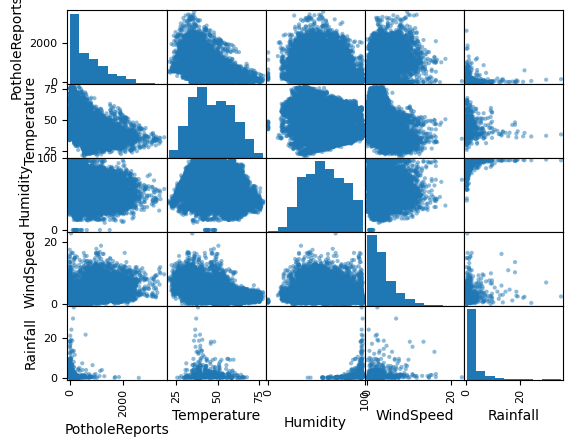

In [3]:
pd.plotting.scatter_matrix(df)

***Insights from the profiling***
- 8232 missing values from `Rainfall`
- `Date` is being read in as an object and not a datetime variable
- distributions skewed left for `PotholeReports`, `WindSpeed`, and `Rainfall` (suggesting outliers on the high side

## 2. Feature Engineering

In [4]:
df.loc[df["Date"] > "2020-05-21", "WindSpeed"] = df["WindSpeed"] / 3.281

In [5]:
df.loc[df["Rainfall"].isna(), "Rainfall"] = 0

In [6]:
df["Date2"] = pd.to_datetime(df["Date"]).copy()
df["Weekday"] = df["Date2"].dt.day_name()
df["Month"] = df["Date2"].dt.month_name()

In [7]:
df.dtypes
df.isna().sum()
df.describe()

Date                        object
PotholeReports               int64
Temperature                float64
Humidity                     int64
WindSpeed                  float64
Rainfall                   float64
ExpectedWorkload            object
Date2               datetime64[ns]
Weekday                     object
Month                       object
dtype: object

Date                0
PotholeReports      0
Temperature         0
Humidity            0
WindSpeed           0
Rainfall            0
ExpectedWorkload    0
Date2               0
Weekday             0
Month               0
dtype: int64

,PotholeReports,Temperature,Humidity,WindSpeed,Rainfall,Date2
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760
mean,704.602055,47.117078,58.226256,1.724871,0.148687,2020-05-20 23:59:59.999999744
min,0.000000,20.600000,0.000000,0.000000,0.000000,2019-11-21 00:00:00
25%,191.000000,37.500000,42.000000,0.900000,0.000000,2020-02-20 00:00:00
50%,504.500000,46.300000,57.000000,1.500000,0.000000,2020-05-21 00:00:00
75%,1065.250000,56.500000,74.000000,2.300000,0.000000,2020-08-20 00:00:00
max,3556.000000,77.800000,98.000000,7.400000,35.000000,2020-11-19 00:00:00
std,644.997468,11.944825,20.362413,1.036286,1.128193,NaN


array([[<Axes: xlabel='PotholeReports', ylabel='PotholeReports'>,
        <Axes: xlabel='Temperature', ylabel='PotholeReports'>,
        <Axes: xlabel='Humidity', ylabel='PotholeReports'>,
        <Axes: xlabel='WindSpeed', ylabel='PotholeReports'>,
        <Axes: xlabel='Rainfall', ylabel='PotholeReports'>],
       [<Axes: xlabel='PotholeReports', ylabel='Temperature'>,
        <Axes: xlabel='Temperature', ylabel='Temperature'>,
        <Axes: xlabel='Humidity', ylabel='Temperature'>,
        <Axes: xlabel='WindSpeed', ylabel='Temperature'>,
        <Axes: xlabel='Rainfall', ylabel='Temperature'>],
       [<Axes: xlabel='PotholeReports', ylabel='Humidity'>,
        <Axes: xlabel='Temperature', ylabel='Humidity'>,
        <Axes: xlabel='Humidity', ylabel='Humidity'>,
        <Axes: xlabel='WindSpeed', ylabel='Humidity'>,
        <Axes: xlabel='Rainfall', ylabel='Humidity'>],
       [<Axes: xlabel='PotholeReports', ylabel='WindSpeed'>,
        <Axes: xlabel='Temperature', ylabel='WindSp

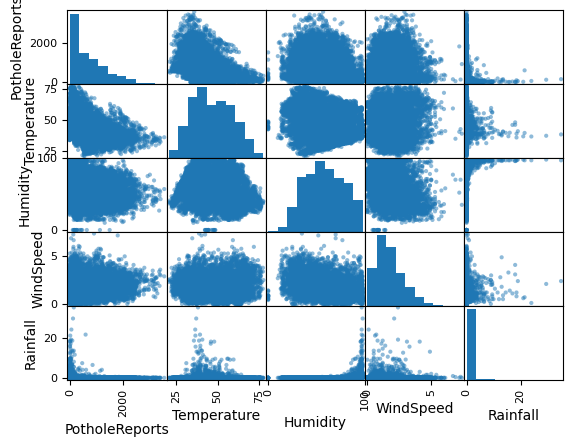

In [8]:
pd.plotting.scatter_matrix(df)

***Insights from Feature Engineering***
- there are no longer any missing values
- there is now a datetime variable, called `Date2`
- still a skew in the data for `PotholeReports`, `Windspeed`, and `Rainfall`

## 3. Predictive Modeling

#### Set-up Outcome and Features

In [9]:
outcome = df["ExpectedWorkload"]

In [10]:
numericFeatures = df[["Temperature", "Humidity", "WindSpeed", "Rainfall"]]
dummies = pd.get_dummies(df[["Weekday", "Month"]], drop_first = True)
features = pd.concat([numericFeatures, dummies], axis = 1)
features

,Temperature,Humidity,WindSpeed,Rainfall,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,...,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,65.2,37,2.200000,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,65.5,38,0.800000,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,66.0,39,1.000000,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,66.2,40,0.900000,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,66.0,36,2.300000,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,55.8,34,2.599873,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
8756,56.6,37,2.299888,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
8757,57.4,39,0.299985,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
8758,57.9,41,0.999951,0.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


#### Partition the Data

In [11]:
from sklearn.model_selection import train_test_split
featuresTrain, featuresTest, outcomeTrain, outcomeTest = train_test_split(features, outcome,
                                                                         test_size = 0.33,
                                                                         random_state = 42)

#### Build and Assess the Model - Decision Tree

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       176
         Low       1.00      1.00      1.00      4492
      Medium       1.00      1.00      1.00      1201

    accuracy                           1.00      5869
   macro avg       1.00      1.00      1.00      5869
weighted avg       1.00      1.00      1.00      5869

              precision    recall  f1-score   support

        High       0.15      0.15      0.15        92
         Low       0.84      0.83      0.84      2227
      Medium       0.36      0.37      0.36       572

    accuracy                           0.72      2891
   macro avg       0.45      0.45      0.45      2891
weighted avg       0.72      0.72      0.72      2891



0.5614388679186666

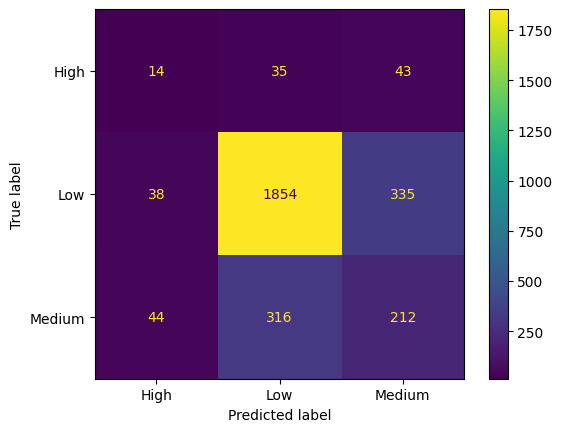

In [12]:
import sklearn.tree
modTree = sklearn.tree.DecisionTreeClassifier(random_state = 42)
modTree.fit(featuresTrain, outcomeTrain)
predTreeTrain = modTree.predict(featuresTrain)
predTreeTest = modTree.predict(featuresTest)
print(sklearn.metrics.classification_report(outcomeTrain, predTreeTrain))
print(sklearn.metrics.classification_report(outcomeTest, predTreeTest))
cmTree = sklearn.metrics.confusion_matrix(outcomeTest, predTreeTest)
sklearn.metrics.ConfusionMatrixDisplay(cmTree, display_labels = modTree.classes_).plot()
predTree = modTree.predict_proba(featuresTest)
fpr_Tree, tpr_Tree, threshold_Tree = sklearn.metrics.roc_curve(outcomeTest, 
                                                               predTree[:,0],
                                                              pos_label = "High")
auc_Tree = sklearn.metrics.auc(fpr_Tree, tpr_Tree)
auc_Tree

#### Build and Assess the Model - Random Forest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       176
         Low       1.00      1.00      1.00      4492
      Medium       1.00      1.00      1.00      1201

    accuracy                           1.00      5869
   macro avg       1.00      1.00      1.00      5869
weighted avg       1.00      1.00      1.00      5869

              precision    recall  f1-score   support

        High       0.21      0.05      0.09        92
         Low       0.84      0.92      0.88      2227
      Medium       0.48      0.35      0.41       572

    accuracy                           0.78      2891
   macro avg       0.51      0.44      0.46      2891
weighted avg       0.75      0.78      0.76      2891



0.8230909330972241

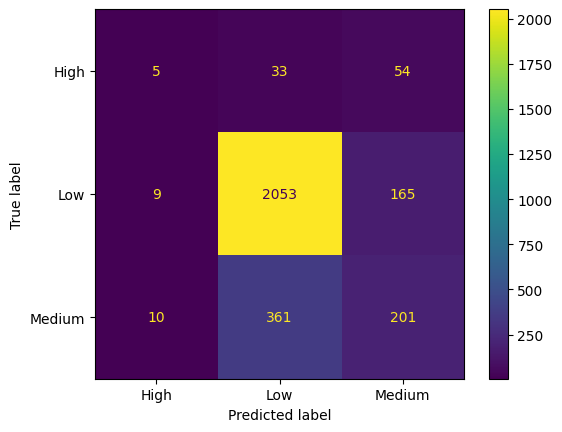

In [13]:
import sklearn.ensemble
modForest = sklearn.ensemble.RandomForestClassifier(random_state = 42)
modForest.fit(featuresTrain, outcomeTrain)
predForestTrain = modForest.predict(featuresTrain)
predForestTest = modForest.predict(featuresTest)
print(sklearn.metrics.classification_report(outcomeTrain, predForestTrain))
print(sklearn.metrics.classification_report(outcomeTest, predForestTest))
cmForest = sklearn.metrics.confusion_matrix(outcomeTest, predForestTest)
sklearn.metrics.ConfusionMatrixDisplay(cmForest, display_labels = modForest.classes_).plot()
predForest = modForest.predict_proba(featuresTest)
fpr_Forest, tpr_Forest, threshold_Forest = sklearn.metrics.roc_curve(outcomeTest, 
                                                               predForest[:,0],
                                                              pos_label = "High")
auc_Forest = sklearn.metrics.auc(fpr_Forest, tpr_Forest)
auc_Forest

#### Build and Assess the Model - SVM

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
featuresTrain_norm = scaler.fit_transform(featuresTrain)
featuresTest_norm = scaler.transform(featuresTest)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


              precision    recall  f1-score   support

        High       0.00      0.00      0.00       176
         Low       0.79      0.99      0.88      4492
      Medium       0.65      0.14      0.24      1201

    accuracy                           0.78      5869
   macro avg       0.48      0.38      0.37      5869
weighted avg       0.74      0.78      0.72      5869

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        92
         Low       0.79      0.99      0.88      2227
      Medium       0.52      0.10      0.16       572

    accuracy                           0.78      2891
   macro avg       0.44      0.36      0.35      2891
weighted avg       0.71      0.78      0.71      2891



/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/tljh/user/lib/python

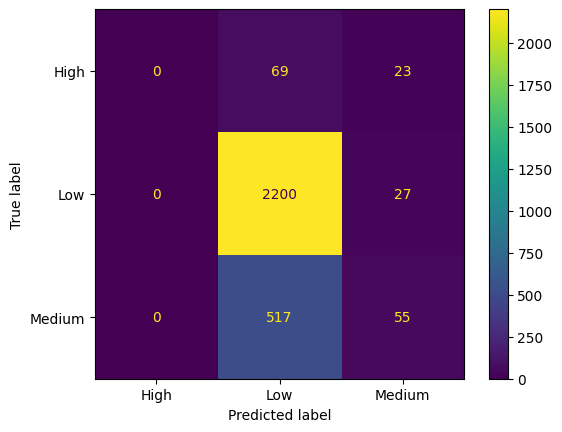

In [15]:
import sklearn.svm
modSVC = sklearn.svm.SVC(random_state = 42)
modSVC.fit(featuresTrain_norm, outcomeTrain)
predSVCTrain = modSVC.predict(featuresTrain_norm)
predSVCTest = modSVC.predict(featuresTest_norm)
print(sklearn.metrics.classification_report(outcomeTrain, predSVCTrain))
print(sklearn.metrics.classification_report(outcomeTest, predSVCTest))
cmSVC = sklearn.metrics.confusion_matrix(outcomeTest, predSVCTest)
sklearn.metrics.ConfusionMatrixDisplay(cmSVC, display_labels = modSVC.classes_).plot()

***Since the `outcome` variable has 3 categories instead of 2, I ran the following code to convert the outcome to True for "High" and False otherwise***

In [17]:
# Get decision scores for all classes
predSVC = modSVC.decision_function(featuresTest_norm)

# Find index of "High"
high_idx = list(modSVC.classes_).index("High")

# Create binary true labels
outcomeTest_binary = (outcomeTest == "High").astype(int)

# Now this will work
fpr_SVC, tpr_SVC, thresholds_SVC = sklearn.metrics.roc_curve(outcomeTest_binary, 
                                                             predSVC[:, high_idx])
auc_SVC = sklearn.metrics.auc(fpr_SVC, tpr_SVC)
auc_SVC

0.8173571306522516

#### Build and Assess the Model - ROC curves

Text(0.5, 0, 'False Positive Rate -->')

Text(0, 0.5, 'True Positive Rate -->')

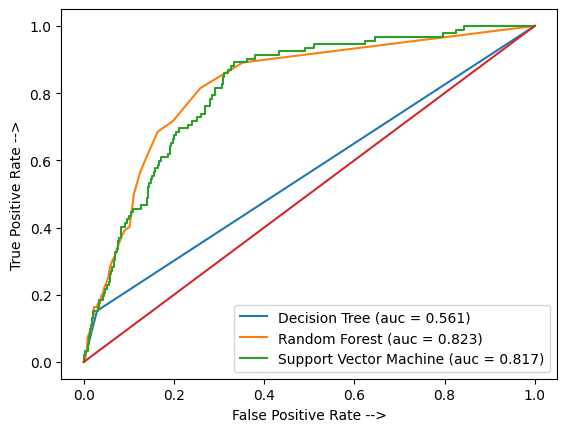

In [18]:
import matplotlib.pyplot as plt

plt.plot(fpr_Tree, tpr_Tree, label = "Decision Tree (auc = %0.3f)" %auc_Tree)
plt.plot(fpr_Forest, tpr_Forest, label = "Random Forest (auc = %0.3f)" %auc_Forest)
plt.plot(fpr_SVC, tpr_SVC, label = "Support Vector Machine (auc = %0.3f)" %auc_SVC)
plt.plot([0,1], [0,1])
plt.legend()
plt.xlabel("False Positive Rate -->")
plt.ylabel("True Positive Rate -->")

***Insights from Predictive Modeling***
- In terms of accuracy on the test data:
    * Tree: 72%
    * Forest: 78%
    * SVC: 78%
- However, there are clear indications of overfitting with the tree and forest models, given that the accuracy on the training data is 100% for both
- There does not appear to be overfitting for the SVC model given that accuracy is 78% for both training and test. However, when looking at the confusion matrix, the model is predicting nothing in the "High" category
- Given that the accuracy % is the same between the forest and SVC models and given that AUC is slightly higher for the forest model, I'd say that the "best" model to predict High workload days is the random forest. However, there's clear overfitting so this is not an ideal model
- The main problem with all 3 models across the board is that there's very little data in the "High" category (only a total of 268 rows in the dataset)

#### 4. Visualization

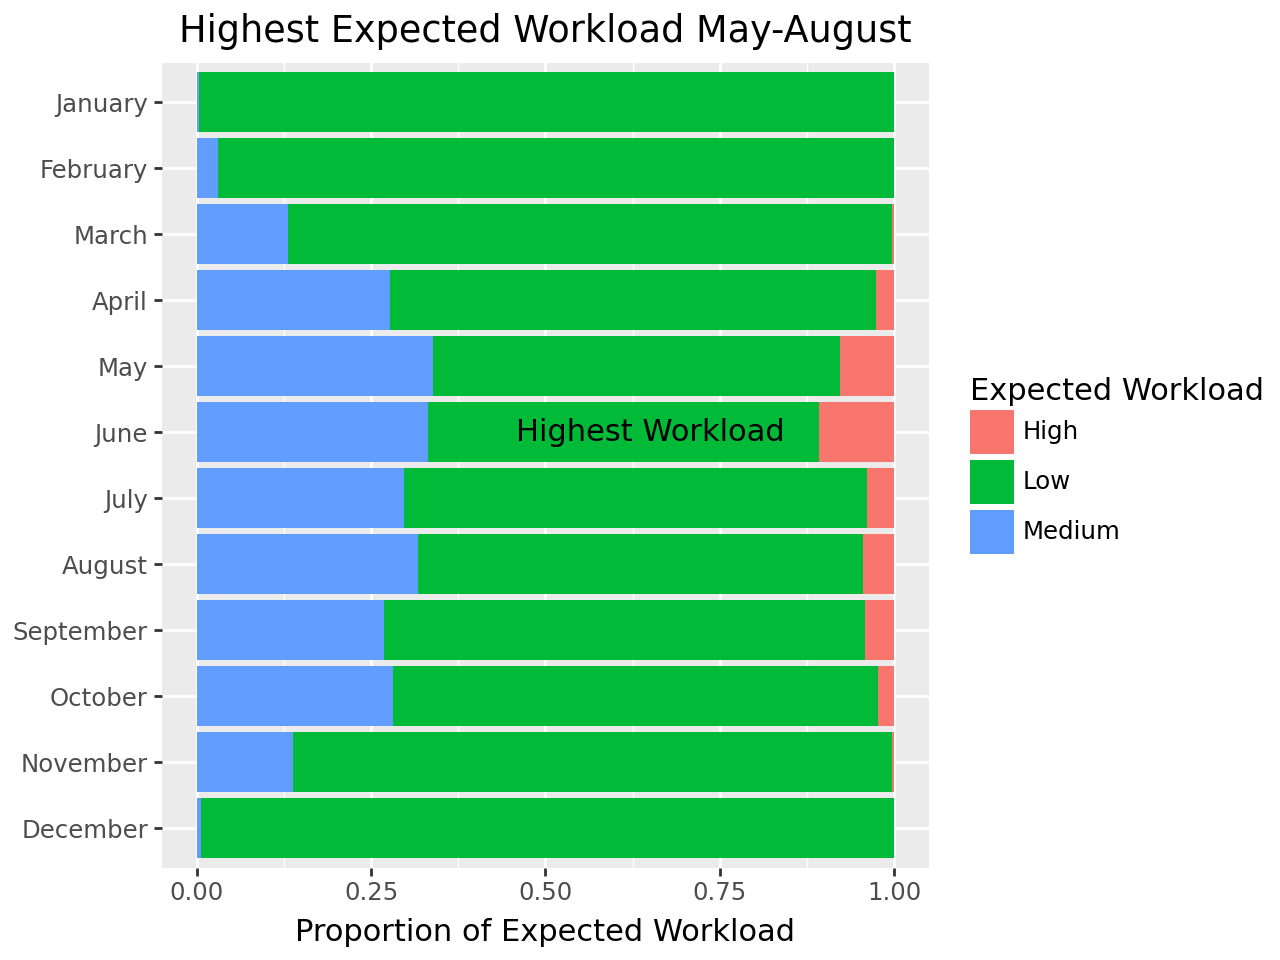

In [20]:
from plotnine import *

(ggplot(df, aes(x = "Month", fill = "ExpectedWorkload")) +
   geom_bar(position = "fill") +
   coord_flip() +
   labs(title = "Highest Expected Workload May-August",
       x = "",
       y = "Proportion of Expected Workload",
       fill = "Expected Workload") +
   scale_x_discrete(limits = ["December", "November", "October",
                             "September", "August", "July",
                             "June", "May", "April",
                             "March", "February", "January"]) +
   annotate("text", label = "Highest Workload",
           x = "June", y = 0.65))